In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap #custom colorbar
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar #for figure scale
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER #for figure scale

import numpy as np
from wrf import latlon_coords, ll_to_xy, xy_to_ll
from netCDF4 import Dataset

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Plot the computational domains (parent and nested) - Figure 1

In [2]:
# Define file path and domain boundaries - from domain 01 - SUBPLOT 1
file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d01_2017-01-12_21:00:00"
# mask
lat_min_d01, lat_max_d01 = -34.14, -33.55
lon_min_d01, lon_max_d01 = 150.57, 151.37

# Load the geo_em file
ds = xr.open_dataset(file_luindex)

# Get coordinates and select first time step (if there's a time dimension)
XLAT = ds["XLAT"].isel(Time=0) if "Time" in ds["XLAT"].dims else ds["XLAT"]
XLONG = ds["XLONG"].isel(Time=0) if "Time" in ds["XLONG"].dims else ds["XLONG"]
LU_INDEX = ds["LU_INDEX"].isel(Time=0) if "Time" in ds["LU_INDEX"].dims else ds["LU_INDEX"]

# Get d01 boundaries
d01_lon_min, d01_lon_max = float(XLONG.min()), float(XLONG.max())
d01_lat_min, d01_lat_max = float(XLAT.min()), float(XLAT.max())

# Create masks
lat_mask = (XLAT >= lat_min_d01) & (XLAT <= lat_max_d01)
lon_mask = (XLONG >= lon_min_d01) & (XLONG <= lon_max_d01)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

# Get data and select first time step if needed
lu_data = ds["LU_INDEX"].isel(Time=0) if "Time" in ds["LU_INDEX"].dims else ds["LU_INDEX"]
lu = lu_data.where(region_mask)

In [3]:
# Load d02 file to get its boundaries - SUBPLOT 1
d02_file = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00"

ds_d02 = xr.open_dataset(d02_file)
XLAT_d02 = ds_d02["XLAT"].isel(Time=0) if "Time" in ds_d02["XLAT"].dims else ds_d02["XLAT"]
XLONG_d02 = ds_d02["XLONG"].isel(Time=0) if "Time" in ds_d02["XLONG"].dims else ds_d02["XLONG"]
# Get d02 boundaries
d02_lon_min, d02_lon_max = float(XLONG_d02.min()), float(XLONG_d02.max())
d02_lat_min, d02_lat_max = float(XLAT_d02.min()), float(XLAT_d02.max())

In [4]:
#BoM stations - SUBPLOT 2
# Define file path and domain boundaries
file_luindex_d02 = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00"

#AWS stations
urbanaws = ['SA','OH','BA','CR','OP']
urbanawslat = [-33.9465, -33.8607, -33.9176, -33.9057, -33.8338]
urbanawslon = [151.1731, 151.205, 150.9837, 151.1134, 151.0718]
urbanawsnm_full = ['SYDNEY AIRPORT AMO', 'SYDNEY (OBSERVATORY HILL)', 'BANKSTOWN AIRPORT AWS', 'CANTERBURY RACECOURSE AWS', 'SYDNEY OLYMPIC PARK AWS (ARCHERY CENTRE)']

#xy of WRF grids corresponding to the stations locations 
awsx_y = ll_to_xy(Dataset(file_luindex_d02), urbanawslat, urbanawslon, stagger=None, as_int=True)
awssn = awsx_y[1].values
awswe = awsx_y[0].values                
#lat/lon of WRF grids corresponding to the stations locations - URBAN ONLY
awsl_l_urban = xy_to_ll(Dataset(file_luindex_d02), awswe, awssn, stagger=None)
awslat_wrf=awsl_l_urban[0].values
awslon_wrf=awsl_l_urban[1].values

In [5]:
# select URBAN-ONLY DCCEEW stations - SUBPLOT 2
# mask
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

#14 DCCEEW stations in Sydney
slat = [-33.93175,-33.86433,-33.78113,-33.93132,-33.91766,-33.89156,-33.91619,-33.61641,-34.30621,-33.79512,-34.05170,-33.79424,-34.05610,-34.04168]
slon = [151.24278,151.16395,151.15090,150.90727,150.76192,151.04610,151.13577,150.74731,150.58061,150.76677,150.49819,150.91417,150.81220,150.69013]
snm = ['RK','RE','LD','LL','BY','CA','ED','RD','BO','SS','OE','PT','CN','CD']
stations = {'RK':'Randwick','RE':'Rozelle','LD':'Lindfield','LL':'Liverpool','BY':'Bringelly','CA':'Chullora','ED':'Earlwood','RD':'Richmond','BO':'Bargo','SS':'St Marys','OE':'Oakdale','PT':'Prospect','CN':'Campbelltown','CD':'Camden'}

# Load the d02 file
ds_d02_right = xr.open_dataset(file_luindex_d02)

# Get coordinates and select first time step (if there's a time dimension)
XLAT_d02_right = ds_d02_right["XLAT"].isel(Time=0) if "Time" in ds_d02_right["XLAT"].dims else ds_d02_right["XLAT"]
XLONG_d02_right = ds_d02_right["XLONG"].isel(Time=0) if "Time" in ds_d02_right["XLONG"].dims else ds_d02_right["XLONG"]
LU_INDEX_d02 = ds_d02_right["LU_INDEX"].isel(Time=0) if "Time" in ds_d02_right["LU_INDEX"].dims else ds_d02_right["LU_INDEX"]

# Create masks
lat_mask_d02 = (XLAT_d02_right >= lat_min) & (XLAT_d02_right <= lat_max)
lon_mask_d02 = (XLONG_d02_right >= lon_min) & (XLONG_d02_right <= lon_max)
lu_mask_d02 = (LU_INDEX_d02 >= 51) & (LU_INDEX_d02 <= 60)
region_mask_d02 = lat_mask_d02 & lon_mask_d02 & lu_mask_d02

# Get data and select first time step if needed
lu_data_d02 = ds_d02_right["LU_INDEX"].isel(Time=0) if "Time" in ds_d02_right["LU_INDEX"].dims else ds_d02_right["LU_INDEX"]
lu_d02 = lu_data_d02.where(region_mask_d02)

#only stations within Sydney lat/lon
snm_indomain=[]
slat_indomain=[]
slon_indomain=[]
# Add station labels
for i, (lon, lat, name) in enumerate(zip(slon, slat, snm)):
    if (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max):
        snm_indomain.append(name)
        slat_indomain.append(lat)
        slon_indomain.append(lon)

#identify stations in URBAN GRIDS ONLY 
stations_indomain = {'RK':'Randwick','RE':'Rozelle','LD':'Lindfield','LL':'Liverpool','BY':'Bringelly','CA':'Chullora','ED':'Earlwood','RD':'Richmond','SS':'St Marys','PT':'Prospect','CN':'Campbelltown','CD':'Camden'}
#xy of WRF grids corresponding to the stations locations within the latlon limit
x_y = ll_to_xy(Dataset(file_luindex_d02), slat_indomain, slon_indomain, stagger=None, as_int=True)
sn = x_y[1].values
we = x_y[0].values

#xy and ll of WRF grids corresponding to the stations locations - ONLY URBAN
snm_urban=[]
sn_urban=[]
we_urban=[]
for i in range(len(snm_indomain)):
    if ds_d02_right['LU_INDEX'].isel(south_north=sn[i], west_east=we[i]).item() > 50:
        snm_urban.append(snm_indomain[i])
        sn_urban.append(sn[i])
        we_urban.append(we[i])      
            
#lat/lon of WRF grids corresponding to the stations locations - URBAN ONLY
l_l_urban = xy_to_ll(Dataset(file_luindex_d02), we_urban, sn_urban, stagger=None)
slat_wrfurban=l_l_urban[0].values
slon_wrfurban=l_l_urban[1].values

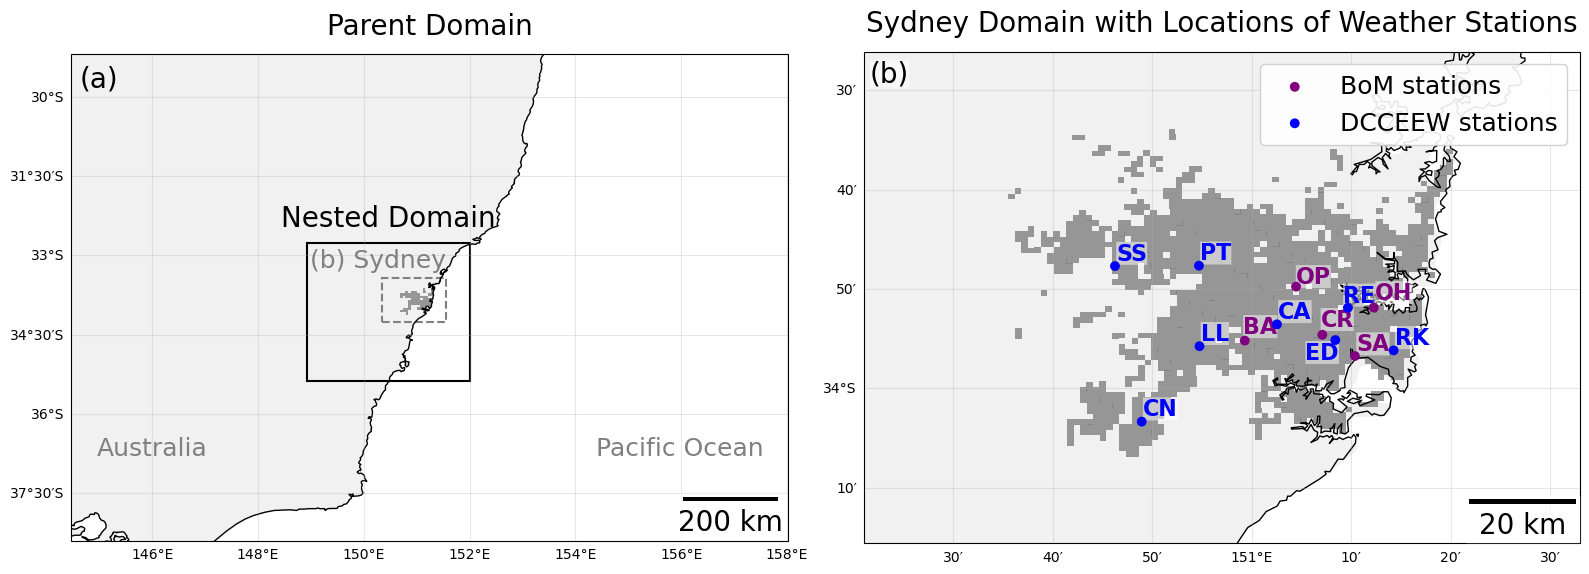

In [ ]:
# plot Figure 1
# Create a single-color colormap for grey
grey_cmap = ListedColormap(['grey'])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# ============= LEFT SUBPLOT (Code 1) =============
# Add map features
ax1.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=1)
ax1.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="gray")
ax1.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)

# Add gridlines
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

# Plot - Note the correct order: XLONG (longitude) first, then XLAT (latitude)
mesh1 = ax1.pcolormesh(XLONG, XLAT, lu, transform=ccrs.PlateCarree(), 
                     cmap=grey_cmap, alpha=0.8, shading='nearest') 

# Add d02 boundary rectangle
d02_rect = mpatches.Rectangle((d02_lon_min, d02_lat_min), 
                               d02_lon_max - d02_lon_min, 
                               d02_lat_max - d02_lat_min,
                               linewidth=1.5, edgecolor='black', facecolor='none',
                               transform=ccrs.PlateCarree())
ax1.add_patch(d02_rect)

lat_min_Syd, lat_max_Syd = -34.259, -33.436
lon_min_Syd, lon_max_Syd = 150.35, 151.55

# Add d02 boundary rectangle
Syd_rect = mpatches.Rectangle((lon_min_Syd, lat_min_Syd), 
                               lon_max_Syd - lon_min_Syd, 
                               lat_max_Syd - lat_min_Syd,
                               linestyle='dashed', linewidth=1.5, edgecolor='grey', facecolor='none',
                               transform=ccrs.PlateCarree())
ax1.add_patch(Syd_rect)

lat_min_d02, lat_max_d02 = -34.259, -33.436#-34.425, -33.27#-34.225, -33.47
lon_min_d02, lon_max_d02 = 150.35, 151.55

# Add text label on top of the rectangle
ax1.text((d02_lon_min + d02_lon_max) / 2 , d02_lat_max+0.2, 'Nested Domain',
        transform=ccrs.PlateCarree(), ha='center', va='bottom',
        fontsize=20, color='black', #fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

# Add text label for Sydney
ax1.text((d02_lon_min + d02_lon_max) / 2 - 0.2, d02_lat_max-0.55, '(b) Sydney',
        transform=ccrs.PlateCarree(), ha='center', va='bottom',
        fontsize=18, color='grey', #fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

# Add text label for Australia
ax1.text(d01_lon_min + 1.5, d01_lat_min + 1.5, 'Australia',
        transform=ccrs.PlateCarree(), ha='center', va='bottom',
        fontsize=18, color='grey',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

# Add text label for Pacific Ocean
ax1.text(d01_lon_max - 2, d01_lat_min + 1.5, 'Pacific Ocean',
        transform=ccrs.PlateCarree(), ha='center', va='bottom',
        fontsize=18, color='grey',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

# Add text label showing the parent domain
ax1.text(d01_lon_min + 0.5, d01_lat_max - 0.7, '(a)',
        transform=ccrs.PlateCarree(), ha='center', va='bottom',
        fontsize=20, color='black', #fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

# Add scale bar
scalebar1 = ScaleBar(dx=111.32, units='km', location='lower right', 
                    length_fraction=0.15, font_properties={'size': 20},
                    box_alpha=0.7, color='black', frameon=True)
ax1.add_artist(scalebar1)

# ============= RIGHT SUBPLOT (Code 2) =============
# Set extent for right subplot
lat_min_Syd, lat_max_Syd = -34.259, -33.436#-34.425, -33.27#-34.225, -33.47
lon_min_Syd, lon_max_Syd = 150.35, 151.55 #150.4, 151.5
ax2.set_extent([lon_min_Syd, lon_max_Syd, lat_min_Syd, lat_max_Syd])

# Add map features
ax2.add_feature(cfeature.GSHHSFeature(scale="h"))
ax2.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)

# Plot - Note the correct order: XLONG (longitude) first, then XLAT (latitude)
mesh2 = ax2.pcolormesh(XLONG_d02_right, XLAT_d02_right, lu_d02, transform=ccrs.PlateCarree(), 
                     alpha=0.8, shading='nearest', cmap = grey_cmap)

# Add AWS stations
ax2.scatter(awslon_wrf, awslat_wrf, c='purple', s=50, marker='o', 
           transform=ccrs.PlateCarree(), zorder=4, edgecolors='none', linewidth=1, label='BoM stations')
# Add station labels
for i, (lon, lat, name) in enumerate(zip(urbanawslon, urbanawslat, urbanaws)):    
        ax2.text(lon + 0.002, lat + 0.002, name, transform=ccrs.PlateCarree(), 
            fontsize=16, ha='left', va='bottom', c='purple', 
            fontweight='bold', bbox=dict(boxstyle='round,pad=0', facecolor='white', edgecolor='none', alpha=0.5))

# Add DCCEEW stations
ax2.scatter(slon_wrfurban, slat_wrfurban, c='blue', s=50, marker='o', 
           transform=ccrs.PlateCarree(), zorder=4, edgecolors='none', linewidth=1, label='DCCEEW stations')
# Add station labels
for i, (lon, lat, name) in enumerate(zip(slon_wrfurban, slat_wrfurban, snm_urban)):
        if name == 'RE':    
            ax2.text(lon - 0.008, lat + 0.002, name, transform=ccrs.PlateCarree(), 
                fontsize=16, ha='left', va='bottom', c='blue', 
                fontweight='bold', bbox=dict(boxstyle='round,pad=0', facecolor='white', edgecolor='none', alpha=0.5))
        elif name == 'ED':    
            ax2.text(lon - 0.05, lat - 0.04, name, transform=ccrs.PlateCarree(), 
                fontsize=16, ha='left', va='bottom', c='blue', 
                fontweight='bold', bbox=dict(boxstyle='round,pad=0', facecolor='white', edgecolor='none', alpha=0.5))
        else:
            ax2.text(lon + 0.002, lat + 0.002, name, transform=ccrs.PlateCarree(), 
                fontsize=16, ha='left', va='bottom', c='blue', 
                fontweight='bold', bbox=dict(boxstyle='round,pad=0', facecolor='white', edgecolor='none', alpha=0.5))

ax2.text(lon_min_d02 + 0.01, lat_max_d02-0.06, "(b)", transform=ccrs.PlateCarree(), 
    fontsize=20, ha='left', va='bottom', c='black',  #fontweight='bold', 
    bbox=dict(boxstyle='round,pad=0', facecolor='white', edgecolor='none', alpha=0.5))


# Add scale bar
scalebar2 = ScaleBar(dx=111.32, units='km', location='lower right', 
                    length_fraction=0.15, font_properties={'size': 20},
                    box_alpha=0.7, color='black', frameon=True)
ax2.add_artist(scalebar2)

# Add legend
ax2.legend(loc='upper right', framealpha=0.9, fontsize=18)

# Add gridlines
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.3)
gl2.top_labels = False
gl2.right_labels = False

# Set titles
ax1.set_title("Parent Domain", fontsize=20, pad=15) #, fontweight='bold'
ax2.set_title("Sydney Domain with Locations of Weather Stations", fontsize=20, pad=15) #, fontweight='bold'
#locations of grids corresponding to weather stations
# Save and show
plt.tight_layout()
plt.savefig("/g/data/gb02/mf9078/plots/Figure1.png", dpi=300, bbox_inches='tight')
plt.show()